# Building a Gym environment and training an RL agent on it

**Setting up a reinforcement learning problem with the help of cleanRL**

Notebooks 1 and 2 in this series had a fixed dataset. This notebook insteaed
considers the reinforcement learning alternative to a dataloader, an **environment**.
We start setting up a **world**, a small grid the agent (which receives observations
and performs actions) can move around in. The "data" is
whatever the agent generates by acting in it.

We build that world from scratch against the standard **Gymnasium** API (the
maintained successor to OpenAI's `gym`), then train an agent to solve it with
[CleanRL](https://github.com/vwxyzjn/cleanrl)'s **PPO** implementation (more about it on Friday).

| Part | Aim |
|---|---|
| 0 | RL Vocabulary recap |
| 1 | `GridWorldEnv`: a custom environment |
| 2 | Baseline: random policy |
| 3 | Training with PPO |
| 4 | Evaluation: training curve, diagnostics, learned path, value function |

**Prerequisites:** notebooks 1–2 (training loops, loss, `DataLoader`). No prior
RL knowledge assumed.

In [18]:
# Gymnasium isn't in every base Python install - grab it if it's missing.
try:
    import gymnasium as gym
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gymnasium"], check=True)
    import gymnasium as gym

import time
import numpy as np
import torch
import torch.nn as nn
from gymnasium import spaces
from gymnasium.wrappers import TimeLimit, RecordEpisodeStatistics
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

torch.manual_seed(0)
rng = np.random.default_rng(0)

# Same visual language as notebooks 1-2: each colour is one identity, everywhere.
C_RANDOM = "#8a8983"   # the random-policy baseline (same "no model" grey as before)
C_PPO    = "#1baf7a"   # the trained agent (green = "the network you trained", as in 1 & 2)
C_TRUTH  = "#0b0b0b"   # start/goal markers, the analytic optimum
C_WALL   = "#3a3a38"

plt.rcParams.update({
    "figure.figsize": (7, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.edgecolor": "#c9c8c4", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "lines.linewidth": 2.0, "font.size": 11, "legend.frameon": False,
})

print("gymnasium", gym.__version__, "| torch", torch.__version__)

gymnasium 1.3.0 | torch 2.7.0


---
# Why RL is a different setup

In notebooks 1–2, we considered supervised learning, which had a steady dataset
with a fixed number of inputs and outputs. In reinforcement learning instead there is an **environment**
the agent interacts with, one step at a time:

1. the environment hands the agent an **observation** of its current situation,
2. the agent picks an **action**,
3. the environment returns a **reward** (a single number saying how good that
   action was) and the **next observation**,
4. repeat, until the episode ends.

| RL term | What we mean | Supervised learning analogue |
|---|---|---|
| observation | what the agent currently sees | a feature vector `x` |
| action | a choice the agent makes | — (nothing like this before) |
| reward | one number, right now, saying how that action went | — closest to `-loss` |
| episode | one full attempt, start to some end condition | one pass through a dataset (epoch) |
| policy | the function mapping observation -> action | the model `f_theta` |
| return | the sum of rewards over an episode | — what we will try to maximise |

RL is based on a feedback loop, not any change to gradient
descent itself, is what makes RL its own subfield.

---
# 1. Building the environment

A Gymnasium environment is any class implementing a small, fixed setup:

* `observation_space` / `action_space`: declare the *shape* of what the agent
  sees and can do, so any algorithm can introspect the environment generically
  instead of being hand-written for it.
* `reset() -> (observation, info)`: start a new episode.
* `step(action) -> (observation, reward, terminated, truncated, info)`: advance
  one timestep. `terminated` means the episode ended *because of the dynamics*
  (goal reached, agent died); `truncated` means an external limit cut it off
  (a step budget). PPO's math needs to treat these two differently, which is
  why Gymnasium keeps them as separate flags.

Our world: a 5x5 grid. The agent starts in the top-left corner and must reach
the bottom-right corner. A short wall down the middle blocks the direct route,
so the agent has to detour around it.

In [19]:
class GridWorldEnv(gym.Env):
    metadata = {"render_modes": ["ansi"]}

    def __init__(self, size=5, walls=((1, 2), (2, 2), (3, 2)), start=(0, 0), goal=(4, 4)):
        super().__init__()
        self.size = size
        self.walls = set(walls)
        self.start = start
        self.goal = goal
        # One-hot over the 25 cells: simple, and makes no assumption that the
        # agent can measure distances - it has to learn the grid's geometry.
        self.observation_space = spaces.Box(0.0, 1.0, shape=(size * size,), dtype=np.float32)
        self.action_space = spaces.Discrete(4)   # 0=up 1=down 2=left 3=right
        self._deltas = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}

    def _dist(self, pos):
        return abs(pos[0] - self.goal[0]) + abs(pos[1] - self.goal[1])

    def _obs(self):
        v = np.zeros(self.size * self.size, dtype=np.float32)
        r, c = self.agent_pos
        v[r * self.size + c] = 1.0
        return v

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.agent_pos = self.start
        return self._obs(), {}

    def step(self, action):
        dr, dc = self._deltas[int(action)]
        r, c = self.agent_pos
        nr, nc = r + dr, c + dc
        old_dist = self._dist(self.agent_pos)
        in_bounds = 0 <= nr < self.size and 0 <= nc < self.size
        if in_bounds and (nr, nc) not in self.walls:
            self.agent_pos = (nr, nc)          # otherwise: bump the wall/edge, stay put
        new_dist = self._dist(self.agent_pos)

        terminated = self.agent_pos == self.goal
        # -1 per step (favours short paths), a small bonus for reducing the
        # distance to the goal (so *any* policy gets some signal, not just one
        # that stumbles onto the goal by luck), +10 on arrival.
        reward = -1.0 + 0.5 * (old_dist - new_dist) + (10.0 if terminated else 0.0)
        return self._obs(), reward, terminated, False, {}

    def render(self):
        rows = []
        for r in range(self.size):
            row = []
            for c in range(self.size):
                if (r, c) == self.agent_pos:
                    row.append("A")
                elif (r, c) == self.goal:
                    row.append("G")
                elif (r, c) in self.walls:
                    row.append("#")
                else:
                    row.append(".")
            rows.append(" ".join(row))
        return "\n".join(rows)

## 1.1 A manual walkthrough

Before any learning algorithm touches this environment, let's drive it by hand
and look at exactly what each method returns — the same "read the actual output"
habit from notebooks 1–2, just applied to a `step()` call instead of a loss.

In [20]:
env = GridWorldEnv()
obs, info = env.reset()
print(f"reset(): obs.shape={obs.shape}, agent at {env.agent_pos}")
print(env.render())

for action, name in [(3, "right"), (3, "right"), (2, "left"), (1, "down")]:
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"\nstep({name:<5}) -> reward={reward:+.2f}  terminated={terminated}  "
          f"truncated={truncated}  agent at {env.agent_pos}")
    print(env.render())

reset(): obs.shape=(25,), agent at (0, 0)
A . . . .
. . # . .
. . # . .
. . # . .
. . . . G

step(right) -> reward=-0.50  terminated=False  truncated=False  agent at (0, 1)
. A . . .
. . # . .
. . # . .
. . # . .
. . . . G

step(right) -> reward=-0.50  terminated=False  truncated=False  agent at (0, 2)
. . A . .
. . # . .
. . # . .
. . # . .
. . . . G

step(left ) -> reward=-1.50  terminated=False  truncated=False  agent at (0, 1)
. A . . .
. . # . .
. . # . .
. . # . .
. . . . G

step(down ) -> reward=-0.50  terminated=False  truncated=False  agent at (1, 1)
. . . . .
. A # . .
. . # . .
. . # . .
. . . . G


The third move (`left`) undoes the second and it
still costs a full `-1` step, which shows how our RL sets aimless movement to be
punished. We can also check that walking straight into the wall means that the agent
simply fails to move.

In [21]:
env2 = GridWorldEnv()
env2.reset()
env2.agent_pos = (1, 1)             # teleport next to the wall, just to test it directly
obs, reward, terminated, truncated, info = env2.step(3)   # try to step right, into (1,2)
print(f"tried to move into a wall cell -> agent stayed at {env2.agent_pos}, reward={reward:+.2f}")

tried to move into a wall cell -> agent stayed at (1, 1), reward=-1.00


## 1.2 Sanity-checking the environment

Gymnasium ships a checker that walks the API for you: correct return
types and shapes, observations that actually lie inside `observation_space`,
and so on. We should run it once before training to catch possible bugs.

In [22]:
from gymnasium.utils.env_checker import check_env

check_env(GridWorldEnv(), skip_render_check=True)
print("check_env: no errors raised")

# A couple of problem-specific invariants check_env can't know about:
probe = GridWorldEnv()
probe.reset()
assert probe.action_space.n == 4
for a in range(4):
    probe.reset()
    _, r, _, _, _ = probe.step(a)
    assert -1.5 <= r <= 10.5, f"reward {r} outside the range the env is designed to produce"
print("action space size and reward range: as expected")

check_env: no errors raised
action space size and reward range: as expected


---
# 2. A baseline: the random policy

As usual we define a **baseline.** Here the
floor is a policy that ignores the observation entirely and picks a uniformly
random action. This is what training should beat.

We wrap the raw environment in Gymnasium's `TimeLimit`. This turns an
open-ended episode into one that eventually reports `truncated=True`, rather
than hand-rolling a step counter inside the environment itself. 

Note that defining a fixed number of steps is also a common way to 
define episode duration.

In [24]:
def make_base_env(max_episode_steps=50):
    return TimeLimit(GridWorldEnv(), max_episode_steps=max_episode_steps)

def run_episode(env, policy):
    # Runs one episode under `policy(obs) -> action`. Returns (path, total_return, length).
    obs, _ = env.reset()
    path = [env.unwrapped.agent_pos]
    total_return, length = 0.0, 0
    terminated = truncated = False
    while not (terminated or truncated):
        action = policy(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        path.append(env.unwrapped.agent_pos)
        total_return += reward
        length += 1
    return path, total_return, length


def random_policy(obs):
    return rng.integers(0, 4)


N_EPISODES = 1000
random_returns, random_lengths = [], []
for _ in range(N_EPISODES):
    _, ret, length = run_episode(make_base_env(), random_policy)
    random_returns.append(ret)
    random_lengths.append(length)

random_returns = np.array(random_returns)
random_lengths = np.array(random_lengths)
random_success = (random_lengths < 50).mean()

print(f"random policy over {N_EPISODES} episodes:")
print(f"  mean return   {random_returns.mean():7.2f}")
print(f"  success rate  {random_success:7.1%}   (reached the goal before the 50-step limit)")
print(f"  mean length   {random_lengths.mean():7.1f} steps")

random policy over 1000 episodes:
  mean return    -41.04
  success rate    23.4%   (reached the goal before the 50-step limit)
  mean length      45.6 steps


Blind exploration finds the goal sometimes. The distance-shaping in the reward
means even a random walk drifts toward it occasionally, but fails more than
three times out of four within the step budget, and the average return is deep
in negative territory. Here's what one such random attempt actually looks like.

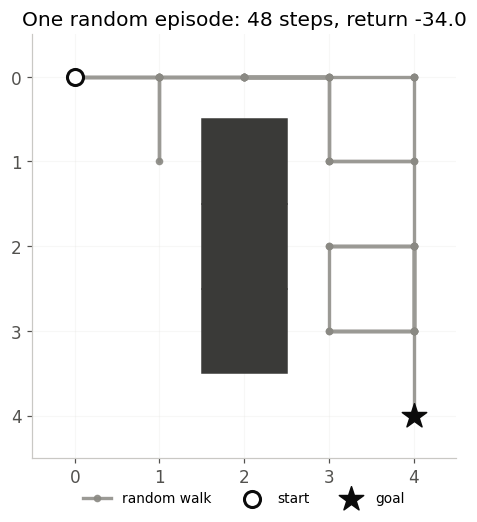

In [26]:
def draw_grid(ax, env, path=None, path_color=C_PPO, path_label=None, values=None):
    size = env.size
    im = None
    if values is not None:
        im = ax.imshow(values, cmap="Blues", vmin=np.nanmin(values), vmax=np.nanmax(values))
    for (r, c) in env.walls:
        ax.add_patch(Rectangle((c - 0.5, r - 0.5), 1, 1, color=C_WALL, zorder=2))
    if path is not None:
        rs = [p[0] for p in path]
        cs = [p[1] for p in path]
        ax.plot(cs, rs, color=path_color, lw=2.2, marker="o", ms=4,
                 label=path_label, zorder=4, alpha=0.85)
    ax.scatter([env.start[1]], [env.start[0]], marker="o", s=110, facecolors="white",
               edgecolors=C_TRUTH, linewidths=2, zorder=5, label="start")
    ax.scatter([env.goal[1]], [env.goal[0]], marker="*", s=280, color=C_TRUTH, zorder=5, label="goal")
    ax.set_xlim(-0.5, size - 0.5)
    ax.set_ylim(size - 0.5, -0.5)
    ax.set_xticks(range(size)); ax.set_yticks(range(size))
    ax.set_aspect("equal")
    ax.grid(True, color="#e3e2de", linewidth=0.8)
    return im


example_path, example_return, example_length = run_episode(make_base_env(), random_policy)

fig, ax = plt.subplots(figsize=(5, 5))
draw_grid(ax, GridWorldEnv(), path=example_path, path_color=C_RANDOM, path_label="random walk")
ax.set_title(f"One random episode: {example_length} steps, return {example_return:.1f}")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=9)
plt.show()

---
# 3. Training an RL problem with PPO

**PPO** (Proximal Policy Optimization) is the algorithm of choice. More about it on Friday.


In [27]:
import sys
import urllib.request
import pathlib
import importlib.util
import inspect

CLEANRL_COMMIT = "e421c2e50b81febf639fced51a69e2602593d50d"
CLEANRL_PPO_URL = f"https://raw.githubusercontent.com/vwxyzjn/cleanrl/{CLEANRL_COMMIT}/cleanrl/ppo.py"

local_path = pathlib.Path("cleanrl_ppo_source.py")
if not local_path.exists():
    urllib.request.urlretrieve(CLEANRL_PPO_URL, local_path)
print(f"fetched {local_path} ({local_path.stat().st_size} bytes) "
      f"from cleanrl @ {CLEANRL_COMMIT[:7]}")

# The fetched file imports `tyro` (their CLI-args library) and `tensorboard`
# at the top level - needed just to *import* the file, even though we'll use
# neither: no command-line parsing, no TensorBoard logging, in this notebook.
try:
    import tyro
    import tensorboard
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "tyro", "tensorboard"], check=True)

# Import it as a module. Its entire training script lives inside
# `if __name__ == "__main__":`, so importing it only defines Agent, layer_init,
# make_env, and the Args config - nothing trains yet.
spec = importlib.util.spec_from_file_location("cleanrl_ppo_source", local_path)
cleanrl_ppo = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = cleanrl_ppo   # so inspect.getsource() below can find it
spec.loader.exec_module(cleanrl_ppo)

Agent = cleanrl_ppo.Agent
layer_init = cleanrl_ppo.layer_init
print("\nimported straight from cleanrl/ppo.py:", Agent, "/", layer_init)

fetched cleanrl_ppo_source.py (12905 bytes) from cleanrl @ e421c2e

imported straight from cleanrl/ppo.py: <class 'cleanrl_ppo_source.Agent'> / <function layer_init at 0x304b84430>


### Vectorized rollout storage

CleanRL runs several environments side by side and collects a fixed number of
steps from each before doing any learning. `SyncVectorEnv` is the built-in
way to do this; the storage tensors below are shaped
`(num_steps, num_envs, ...)`, filled in one timestep at a time across all
environments at once.

In [29]:
def make_env():
    def thunk():
        e = GridWorldEnv()
        e = TimeLimit(e, max_episode_steps=50)
        e = RecordEpisodeStatistics(e)     # tracks each episode's total return and length
        return e
    return thunk


# ----- hyperparameters (small-problem-sized versions of CleanRL's PPO defaults) -----
num_envs = 8
num_steps = 64                 # steps collected per env before each update
total_timesteps = 51_200
batch_size = num_envs * num_steps
num_minibatches = 4
minibatch_size = batch_size // num_minibatches
update_epochs = 4              # passes over each batch of rollout data
gamma = 0.99                   # discount factor
gae_lambda = 0.95               # bias/variance trade-off in the advantage estimate
clip_coef = 0.2                # how far the policy is allowed to move in one update
ent_coef = 0.01                # entropy bonus - keeps some exploration alive
vf_coef = 0.5
max_grad_norm = 0.5
learning_rate = 1e-3

envs = gym.vector.SyncVectorEnv([make_env() for _ in range(num_envs)])
assert isinstance(envs.single_action_space, spaces.Discrete), "PPO here only supports discrete actions"

torch.manual_seed(0)
agent = Agent(envs)          # their exact constructor: it reads the shapes off `envs` itself
optimizer = torch.optim.Adam(agent.parameters(), lr=learning_rate, eps=1e-5)

obs      = torch.zeros((num_steps, num_envs) + envs.single_observation_space.shape)
actions  = torch.zeros((num_steps, num_envs) + envs.single_action_space.shape)
logprobs = torch.zeros((num_steps, num_envs))
rewards  = torch.zeros((num_steps, num_envs))
dones    = torch.zeros((num_steps, num_envs))
values   = torch.zeros((num_steps, num_envs))

num_iterations = total_timesteps // batch_size
print(f"{num_iterations} iterations of {batch_size} timesteps each = {num_iterations * batch_size} total")

100 iterations of 512 timesteps each = 51200 total


## 3.3 The training loop


In [31]:
next_obs, _ = envs.reset(seed=0)
next_obs = torch.tensor(next_obs, dtype=torch.float32)
next_done = torch.zeros(num_envs)

episodic_returns = []          # (timestep, return) for every episode that finishes
diagnostics = []               # (timestep, approx_kl, clipfrac) per PPO update
t0 = time.time()

for iteration in range(num_iterations):
    # ---- 1. collect a rollout with the CURRENT policy (no gradients here) ----
    for step in range(num_steps):
        obs[step] = next_obs
        dones[step] = next_done
        with torch.no_grad():
            action, logprob, _, value = agent.get_action_and_value(next_obs)
            values[step] = value.flatten()
        actions[step] = action
        logprobs[step] = logprob

        next_obs_np, reward, terminations, truncations, infos = envs.step(action.numpy())
        next_done_np = np.logical_or(terminations, truncations)
        rewards[step] = torch.tensor(reward, dtype=torch.float32)
        next_obs = torch.tensor(next_obs_np, dtype=torch.float32)
        next_done = torch.tensor(next_done_np, dtype=torch.float32)

        if "episode" in infos:
            mask = infos["_episode"]
            t_now = (iteration * num_steps + step + 1) * num_envs
            episodic_returns += [(t_now, r) for r in infos["episode"]["r"][mask]]

    # ---- 2. GAE: turn raw rewards into an advantage estimate for each step ----
    with torch.no_grad():
        next_value = agent.get_value(next_obs).reshape(1, -1)
        advantages = torch.zeros_like(rewards)
        lastgaelam = 0.0
        for t in reversed(range(num_steps)):
            if t == num_steps - 1:
                nextnonterminal = 1.0 - next_done
                nextvalues = next_value
            else:
                nextnonterminal = 1.0 - dones[t + 1]
                nextvalues = values[t + 1]
            delta = rewards[t] + gamma * nextvalues * nextnonterminal - values[t]
            advantages[t] = lastgaelam = delta + gamma * gae_lambda * nextnonterminal * lastgaelam
        returns = advantages + values

    # ---- 3. PPO update: several epochs over shuffled minibatches of this rollout ----
    b_obs = obs.reshape((-1,) + envs.single_observation_space.shape)
    b_logprobs = logprobs.reshape(-1)
    b_actions = actions.reshape((-1,) + envs.single_action_space.shape)
    b_advantages = advantages.reshape(-1)
    b_returns = returns.reshape(-1)
    b_values = values.reshape(-1)

    b_inds = np.arange(batch_size)
    clipfracs = []
    for epoch in range(update_epochs):
        np.random.shuffle(b_inds)
        for start in range(0, batch_size, minibatch_size):
            end = start + minibatch_size
            mb_inds = b_inds[start:end]

            _, newlogprob, entropy, newvalue = agent.get_action_and_value(
                b_obs[mb_inds], b_actions.long()[mb_inds])
            logratio = newlogprob - b_logprobs[mb_inds]
            ratio = logratio.exp()

            with torch.no_grad():
                # http://joschu.net/blog/kl-approx.html
                approx_kl = ((ratio - 1) - logratio).mean()
                clipfracs += [((ratio - 1.0).abs() > clip_coef).float().mean().item()]

            mb_advantages = b_advantages[mb_inds]
            mb_advantages = (mb_advantages - mb_advantages.mean()) / (mb_advantages.std() + 1e-8)

            pg_loss1 = -mb_advantages * ratio
            pg_loss2 = -mb_advantages * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
            pg_loss = torch.max(pg_loss1, pg_loss2).mean()

            # clipped value loss: also keeps the *critic* from moving too far in one update
            newvalue = newvalue.view(-1)
            v_loss_unclipped = (newvalue - b_returns[mb_inds]) ** 2
            v_clipped = b_values[mb_inds] + torch.clamp(
                newvalue - b_values[mb_inds], -clip_coef, clip_coef)
            v_loss_clipped = (v_clipped - b_returns[mb_inds]) ** 2
            v_loss = 0.5 * torch.max(v_loss_unclipped, v_loss_clipped).mean()

            entropy_loss = entropy.mean()
            loss = pg_loss - ent_coef * entropy_loss + v_loss * vf_coef

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
            optimizer.step()

    diagnostics.append((iteration * batch_size, approx_kl.item(), np.mean(clipfracs)))

    if (iteration + 1) % 10 == 0 or iteration == 0:
        recent = [r for _, r in episodic_returns[-50:]] or [float("nan")]
        print(f"iteration {iteration + 1:3d}/{num_iterations}   "
              f"timesteps {(iteration + 1) * batch_size:6d}   "
              f"recent mean return {np.mean(recent):7.2f}   "
              f"approx_kl {approx_kl.item():.4f}   clipfrac {np.mean(clipfracs):.3f}")

print(f"\ntraining time: {time.time() - t0:.1f}s")

iteration   1/100   timesteps    512   recent mean return    6.00   approx_kl 0.0006   clipfrac 0.008
iteration  10/100   timesteps   5120   recent mean return    6.00   approx_kl 0.0018   clipfrac 0.013
iteration  20/100   timesteps  10240   recent mean return    6.00   approx_kl 0.0061   clipfrac 0.074
iteration  30/100   timesteps  15360   recent mean return    6.00   approx_kl 0.0071   clipfrac 0.014
iteration  40/100   timesteps  20480   recent mean return    6.00   approx_kl 0.0002   clipfrac 0.007
iteration  50/100   timesteps  25600   recent mean return    6.00   approx_kl 0.0004   clipfrac 0.000
iteration  60/100   timesteps  30720   recent mean return    6.00   approx_kl 0.0193   clipfrac 0.025
iteration  70/100   timesteps  35840   recent mean return    6.00   approx_kl 0.0044   clipfrac 0.038
iteration  80/100   timesteps  40960   recent mean return    6.00   approx_kl 0.0021   clipfrac 0.008
iteration  90/100   timesteps  46080   recent mean return    6.00   approx_kl 0.00

---
# 4. Evaluation

## 4.1 The training curve, against two reference lines

We can now evaluate our model, the random-policy mean return from Part 2
(the floor), and the **analytic optimum** — computed directly from the reward
formula in Part 1. The shortest path around the wall is 8
steps; each step costs `-1` but earns back `+0.5` for approaching the goal, plus
`+10` on arrival:

In [33]:
optimal_path_length = 8
optimal_return = optimal_path_length * (-1.0 + 0.5) + 10.0
print(f"optimal path length : {optimal_path_length} steps")
print(f"optimal return       : {optimal_return:.2f}  (the ceiling, no policy can beat this)")

optimal path length : 8 steps
optimal return       : 6.00  (the ceiling, no policy can beat this)


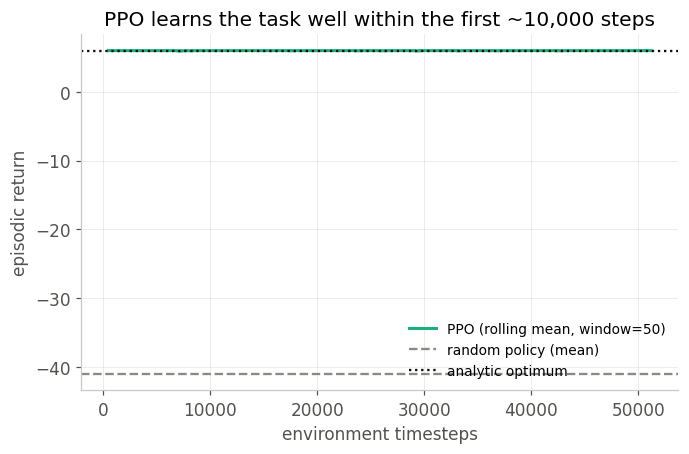

final 50-episode mean return: 6.00


In [34]:
ts = np.array([t for t, _ in episodic_returns])
rs = np.array([r for _, r in episodic_returns])

# a rolling mean over episodes makes the trend readable through per-episode noise
window = 50
roll_mean = np.convolve(rs, np.ones(window) / window, mode="valid")
roll_ts = ts[window - 1:]

fig, ax = plt.subplots()
ax.plot(roll_ts, roll_mean, color=C_PPO, label=f"PPO (rolling mean, window={window})")
ax.axhline(random_returns.mean(), color=C_RANDOM, ls="--", lw=1.5, label="random policy (mean)")
ax.axhline(optimal_return, color=C_TRUTH, ls=":", lw=1.5, label="analytic optimum")
ax.set(xlabel="environment timesteps", ylabel="episodic return",
       title="PPO learns the task well within the first ~10,000 steps")
ax.legend(loc="lower right", fontsize=9)
plt.show()

print(f"final 50-episode mean return: {np.mean(rs[-50:]):.2f}")

## 4.2 What the trained policy actually does

We roll out the learnt deterministic policy (always take the highest-probability action, no more
exploring) and compare its path to the random walk from Part 2.

trained policy: 8 steps, return 6.00  (optimal: 8 steps, return 6.00)


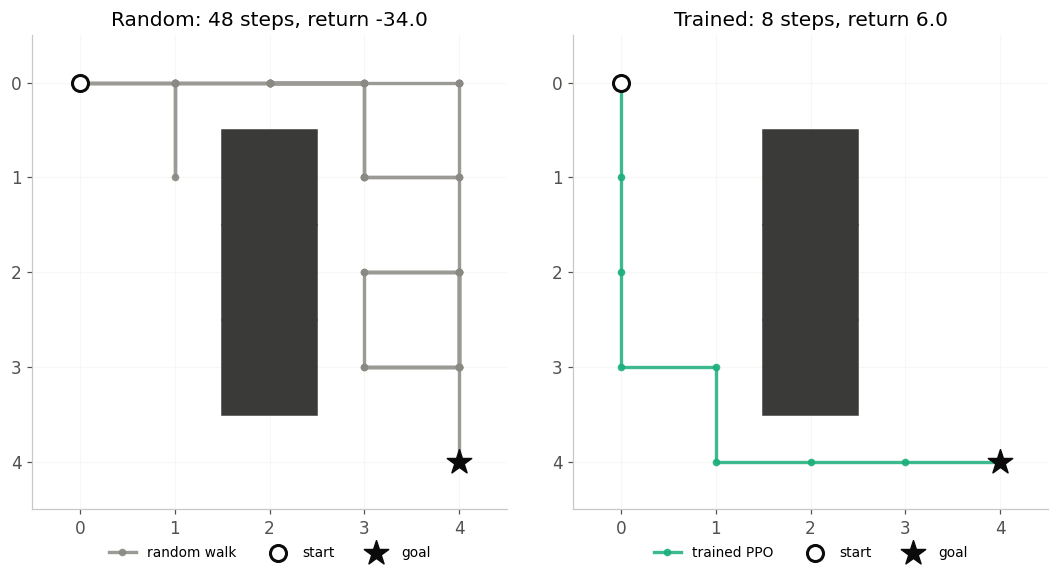

In [37]:
def greedy_policy(obs):
    with torch.no_grad():
        logits = agent.actor(torch.tensor(obs, dtype=torch.float32).unsqueeze(0))
        return logits.argmax(dim=-1).item()

trained_path, trained_return, trained_length = run_episode(make_base_env(), greedy_policy)
print(f"trained policy: {trained_length} steps, return {trained_return:.2f}  "
      f"(optimal: {optimal_path_length} steps, return {optimal_return:.2f})")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
draw_grid(axes[0], GridWorldEnv(), path=example_path, path_color=C_RANDOM, path_label="random walk")
axes[0].set_title(f"Random: {example_length} steps, return {example_return:.1f}")
draw_grid(axes[1], GridWorldEnv(), path=trained_path, path_color=C_PPO, path_label="trained PPO")
axes[1].set_title(f"Trained: {trained_length} steps, return {trained_return:.1f}")
for ax in axes:
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=9)
plt.tight_layout(); plt.show()